# PROCESS large tokamak — plasma-input variants

Nine evaluation-mode runs in `reference/plasma_variants/`: a baseline plus
`alphat`, `alphan`, `kappa` and the xenon fraction each moved above and below it.

The deliverable is the **differential**. Single-point agreement is weak evidence
when the fixture supplies most of the design vector; asking whether fusdb *moves
the same way* PROCESS does is much harder to pass by accident.

In [1]:
# Validated categorical order (dataviz palette): slot 1 blue, slot 2 orange.
# Two series only, assigned in fixed order and never cycled.
FUSDB, PROCESS = '#2a78d6', '#eb6834'
import matplotlib.pyplot as plt, numpy as np, sys
sys.path.insert(0, '.')
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':0.25, 'grid.linewidth':0.6,
                     'axes.labelcolor':'#52514e', 'text.color':'#0b0b0b',
                     'xtick.color':'#52514e', 'ytick.color':'#52514e', 'font.size':9})

from _process_compare import compare
from _process_fixture import plasma_variants
V = plasma_variants()
res = {tag: compare(path) for tag, path in V.items()}
base = res['baseline'][0]
tags = [t for t in sorted(res) if t != 'baseline'
        and res[t][1]['regime'] == 'h_mode']
FIELDS = ['P_fus','P_rad','W_th','tau_E','V_p']
print('H-mode variants compared:', len(tags))
for t in sorted(res):
    print(f"  {t:34s} {res[t][1]['regime']}")

/home/alessmor/Scrivania/fusdb/src/fusdb/relations/confinement/scalings/ITER.py:900: RuntimeWarning: invalid value encountered in scalar power
  * p_plasma_loss_mw ** (-0.69e0)
/home/alessmor/Scrivania/fusdb/src/fusdb/relations/confinement/scalings/ITER.py:74: RuntimeWarning: invalid value encountered in sqrt
  / np.sqrt(p_plasma_loss_mw)


H-mode variants compared: 7
  alphan_1.200e+00                   h_mode
  alphan_8.000e-01                   h_mode
  alphat_1.200e+00                   h_mode
  alphat_1.700e+00                   h_mode
  baseline                           h_mode
  fndimpurityelectrons13_3.000e-04   h_mode
  fndimpurityelectrons13_9.000e-04   l_mode
  kappa_1.750e+00                    h_mode
  kappa_1.950e+00                    h_mode


## Response to each perturbation

Percentage change from the baseline, fusdb beside PROCESS. Agreement here means
the two codes have the same *sensitivity*, independent of any shared offset.

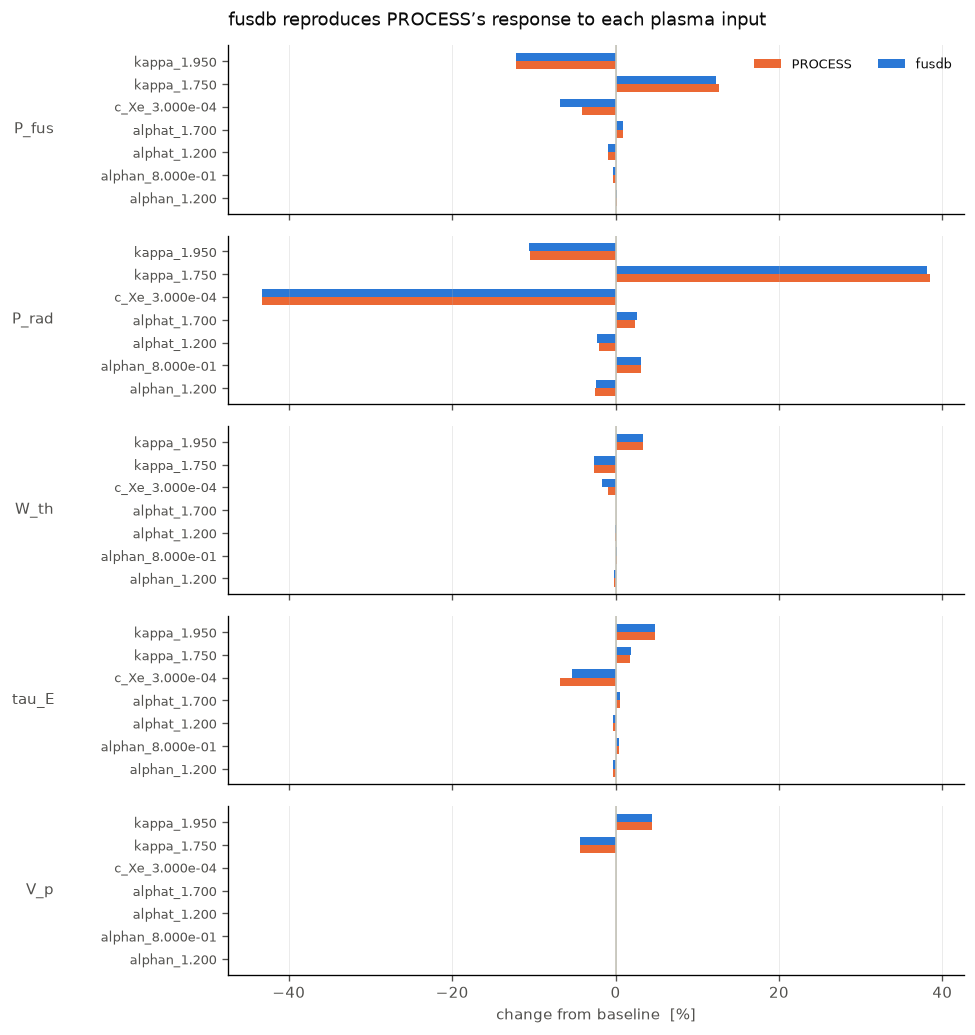

In [2]:
fig, axes = plt.subplots(len(FIELDS), 1, figsize=(8.2, 1.5*len(FIELDS)+1.2), sharex=True)
y = np.arange(len(tags)); h = 0.36
for ax, key in zip(axes, FIELDS):
    df = [100*(res[t][0][key]['fusdb']/base[key]['fusdb']-1) for t in tags]
    dp = [100*(res[t][0][key]['process']/base[key]['process']-1) for t in tags]
    ax.barh(y-h/2, dp, height=h, color=PROCESS, label='PROCESS')
    ax.barh(y+h/2, df, height=h, color=FUSDB, label='fusdb')
    ax.axvline(0, color='#c3c2b7', lw=1)
    ax.set_yticks(y); ax.set_yticklabels([t.replace('e+00','').replace('fndimpurityelectrons13','c_Xe')
                                          for t in tags], fontsize=7.5)
    ax.set_ylabel(key, rotation=0, ha='right', va='center', labelpad=28)
    ax.grid(axis='y', visible=False)
axes[0].legend(frameon=False, fontsize=8, ncol=2, loc='upper right')
axes[-1].set_xlabel('change from baseline  [%]')
axes[0].set_title('fusdb reproduces PROCESS\u2019s response to each plasma input',
                  loc='left', pad=12)
fig.tight_layout()

## Response agreement

The residual: how far fusdb's response differs from PROCESS's, in percentage
points. The test asserts each of these is within 10.

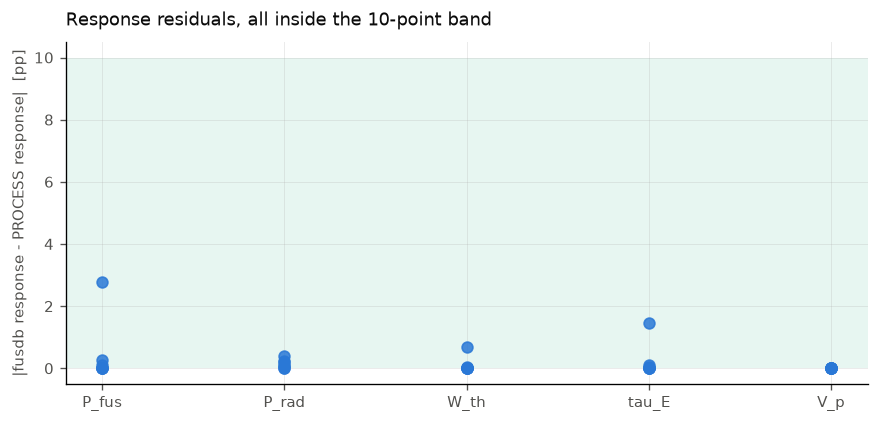

In [3]:
fig, ax = plt.subplots(figsize=(7.4, 3.6))
resid = {k: [abs(100*(res[t][0][k]['fusdb']/base[k]['fusdb']-1)
                 - 100*(res[t][0][k]['process']/base[k]['process']-1)) for t in tags]
         for k in FIELDS}
ax.axhspan(0, 10, color='#1baf7a', alpha=0.10, lw=0)
for i, k in enumerate(FIELDS):
    ax.scatter([i]*len(tags), resid[k], s=42, color=FUSDB, zorder=3, alpha=0.85)
ax.set_xticks(range(len(FIELDS))); ax.set_xticklabels(FIELDS)
ax.set_ylabel('|fusdb response - PROCESS response|  [pp]')
ax.set_title('Response residuals, all inside the 10-point band', loc='left', pad=10)
fig.tight_layout()